In [1]:
import math
import pickle
import itertools
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
})

np.random.seed(420)

## 1. Carga de Datos

In [2]:
class CloudscapeDataset:
    def __init__(self, df_architectures, df_nodes, df_edges, graphs):
        self.architectures = df_architectures
        self.nodes = df_nodes
        self.edges = df_edges
        self.graphs = graphs

In [3]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
SERVICES_CSV = DATA_DIR / "services.csv"
BUNDLE_PATH = BASE_DIR / "output_analytics" / "cloudscape_pipeline_bundle.pkl"

if not BUNDLE_PATH.exists():
    raise FileNotFoundError(f"No se encontro el bundle en {BUNDLE_PATH}")

with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

df_services_master: pl.DataFrame = bundle["df_services_master"]
df_cooccurrences: pl.DataFrame = bundle["df_cooccurrences"]
df_transitions = bundle.get("df_transitions")
G_cooc_master: nx.Graph = bundle["G_cooc_master"]

print(f"Servicios en grafo: {G_cooc_master.number_of_nodes()}")
print(f"Aristas: {G_cooc_master.number_of_edges()}")
print(f"Servicios en catalogo: {df_services_master.height}")

Servicios en grafo: 78
Aristas: 491
Servicios en catalogo: 160


## 2. Utilidades Comunes

In [4]:
df_services_cat = pl.read_csv(SERVICES_CSV).select(['name', 'aws_product_categories'])
cat_map_raw = {}
for row in df_services_cat.iter_rows(named=True):
    cats = [c.strip() for c in row['aws_product_categories'].split(',')] if row['aws_product_categories'] else []
    cat_map_raw[row['name']] = cats

GROUP_MAPPING = {
    'Compute': ['Compute'],
    'Storage': ['Storage'],
    'Networking': ['Networking and Content Delivery'],
    'Integration': ['Application Integration'],
    'Analytics': ['Analytics'],
    'Security': ['Security Identity and Compliance'],
    'Management': ['Management and Governance'],
    'IoT': ['IoT'],
    'Media': ['Media Services'],
    'Developer': ['Developer Tools'],
    'Database': ['Database'],
    'ML': ['ML'],
    'Other': [],
}


def get_service_category(service: str) -> str:
    cats = cat_map_raw.get(service, [])
    for group, keywords in GROUP_MAPPING.items():
        for kw in keywords:
            if any(kw in c for c in cats):
                return group
    cap_rows = df_services_master.filter(pl.col('service') == service)['capability']
    cap = cap_rows.first() if len(cap_rows) > 0 else None
    return {
        'compute': 'Compute', 'storage': 'Storage',
        'networking': 'Networking', 'integration': 'Integration',
    }.get(cap, 'Other')

In [5]:
POPULARIDAD = {
    row['service']: row['num_architectures']
    for row in df_services_master.iter_rows(named=True)
}
PESO_BASE = {
    row['service']: row['base_prob_weight']
    for row in df_services_master.iter_rows(named=True)
}


def popularidad(servicio: str) -> int:
    return POPULARIDAD.get(servicio, 0)


def peso(servicio: str) -> float:
    return PESO_BASE.get(servicio, 0.0)

In [6]:
def son_incompatibles(s1: str, s2: str, G: nx.Graph = None) -> bool:
    if G is None:
        G = G_cooc_master
    if s1 == s2:
        return False
    if not G.has_node(s1) or not G.has_node(s2):
        return True
    return not G.has_edge(s1, s2)


def hay_conflicto_interno(servicio: str, miembros: list, G: nx.Graph = None):
    if G is None:
        G = G_cooc_master
    for m in miembros:
        if son_incompatibles(servicio, m, G):
            return m
    return None


def hay_conflicto_con_otros_dados(servicio: str, dados: dict, excluir=None, G: nx.Graph = None):
    if G is None:
        G = G_cooc_master
    for dado_id, miembros in dados.items():
        if dado_id == excluir:
            continue
        conflicto = hay_conflicto_interno(servicio, miembros, G)
        if conflicto:
            return (dado_id, conflicto)
    return None


def tasa_incompatibilidad(servicio: str, grupo: list, G: nx.Graph = None) -> float:
    if G is None:
        G = G_cooc_master
    if not grupo:
        return 0.0
    choques = sum(1 for o in grupo if son_incompatibles(servicio, o, G))
    return choques / len(grupo)

In [7]:
def encontrar_conflictos_globales(dados: dict, G: nx.Graph = None):
    if G is None:
        G = G_cooc_master
    conflictos = []
    ids = list(dados.keys())
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            for s1 in dados[ids[i]]:
                for s2 in dados[ids[j]]:
                    if son_incompatibles(s1, s2, G):
                        conflictos.append((ids[i], s1, ids[j], s2))
    return conflictos


def asegurar_sin_incompatibilidades(dados: dict, nombre_metodo: str,
                                     G: nx.Graph = None, verbose: bool = True):
    if G is None:
        G = G_cooc_master
    dados = {k: list(v) for k, v in dados.items()}
    removidos = []

    conflictos = encontrar_conflictos_globales(dados, G)
    intentos = 0
    while conflictos and intentos < 500:
        dado_a, s1, dado_b, s2 = conflictos[0]
        perdedor, dado_perdedor = (s1, dado_a) if popularidad(s1) < popularidad(s2) else (s2, dado_b)
        if perdedor in dados[dado_perdedor]:
            dados[dado_perdedor].remove(perdedor)
            removidos.append(perdedor)
            if verbose:
                print(f"Removido: {perdedor} de {dado_perdedor}")
        dados = {k: v for k, v in dados.items() if v}
        conflictos = encontrar_conflictos_globales(dados, G)
        intentos += 1

    if verbose:
        if removidos:
            print(f"{nombre_metodo}: {len(removidos)} conflictos reparados")
        else:
            print(f"{nombre_metodo}: sin conflictos")

    return dados, removidos

## 3. Metodo V3

In [8]:
def _rankear_por_prioridad(candidatos: list, grupo_externo: list, G: nx.Graph = None) -> list:
    if G is None:
        G = G_cooc_master
    ranking = []
    for c in candidatos:
        inc_ext = sum(1 for o in grupo_externo if son_incompatibles(c, o, G))
        ranking.append((inc_ext, -popularidad(c), c))
    ranking.sort()
    return [c for _, _, c in ranking]


def _filtrar_toxicos(candidatos: list, grupos_referencia: list, umbrales: list, G: nx.Graph = None):
    if G is None:
        G = G_cooc_master
    sociables, toxicos = [], []
    for c in candidatos:
        tasas = [tasa_incompatibilidad(c, grupo, G) for grupo in grupos_referencia]
        if all(t <= u for t, u in zip(tasas, umbrales)):
            sociables.append(c)
        else:
            toxicos.append(c)
    return sociables, toxicos

In [9]:
def _construir_dados_cabecera(nombre_categoria: str, candidatos_categoria: list,
                               grupos_externos: list, umbrales_toxicidad: list,
                               dados_creados: dict, n_dados: int, target_caras: int,
                               G: nx.Graph = None, verbose: bool = True):
    if G is None:
        G = G_cooc_master
    grupo_externo_total = [s for g in grupos_externos for s in g]
    sociables, toxicos = _filtrar_toxicos(candidatos_categoria, grupos_externos, umbrales_toxicidad, G)
    pool = sociables if sociables else candidatos_categoria
    ordenados = _rankear_por_prioridad(pool, grupo_externo_total, G)

    n_dados = max(1, n_dados)
    caras_por_dado = max(1, target_caras)
    seleccionados_total = ordenados[: n_dados * caras_por_dado]
    sobrantes = ordenados[n_dados * caras_por_dado:] + toxicos

    grupos = [[] for _ in range(n_dados)]
    for idx, s in enumerate(seleccionados_total):
        grupos[idx % n_dados].append(s)

    for i, miembros in enumerate(grupos):
        if not miembros:
            continue
        dado_id = f"Dado_{nombre_categoria}" if n_dados == 1 else f"Dado_{nombre_categoria}_{i + 1}"
        dados_creados[dado_id] = miembros
        if verbose:
            print(f"{dado_id}: {miembros}")

    devueltos, descartados = [], []
    for s in sobrantes:
        conflicto = hay_conflicto_con_otros_dados(s, dados_creados, excluir=None, G=G)
        if conflicto:
            descartados.append(s)
            if verbose:
                print(f"Descartado {s}: incompatible con {conflicto[1]}")
        else:
            devueltos.append(s)
    return devueltos, descartados

In [10]:
def construir_dados_v3(
    df_services_master: pl.DataFrame,
    G: nx.Graph = None,
    umbral_min_archs: int = 20,
    max_incomp_compute_storage: float = 0.40,
    max_incomp_compute_resto: float = 0.30,
    max_incomp_storage_resto: float = 0.50,
    variante: str = "original",
    target_caras_por_dado: int = 4,
    min_caras_dado: int = 3,
    max_caras_dado: int = 6,
    verbose: bool = True,
):

    if G is None:
        G = G_cooc_master

    df_aws = df_services_master.filter(
        (pl.col('is_aws') == True) & (pl.col('num_architectures') >= umbral_min_archs)
    ).sort('num_architectures', descending=True)

    servicios_base = df_aws['service'].to_list()
    cats_base = {s: get_service_category(s) for s in servicios_base}

    stack_compute = [s for s in servicios_base if cats_base[s] == 'Compute']
    stack_storage = [s for s in servicios_base if cats_base[s] == 'Storage']
    otros = [s for s in servicios_base if cats_base[s] not in ('Compute', 'Storage')]

    dados = {}
    descartados = []

    if verbose:
        print(f"Compute: {len(stack_compute)} Storage: {len(stack_storage)} Otros: {len(otros)}")

    if variante == "mejorado":
        socc_compute, _ = _filtrar_toxicos(stack_compute, [stack_storage, otros],
                                            [max_incomp_compute_storage, max_incomp_compute_resto], G)
        socc_storage, _ = _filtrar_toxicos(stack_storage, [otros],
                                            [max_incomp_storage_resto], G)
        base_compute = socc_compute if socc_compute else stack_compute
        base_storage = socc_storage if socc_storage else stack_storage
        n_dados_compute = max(1, math.ceil(len(base_compute) / target_caras_por_dado)) if base_compute else 1
        n_dados_storage = max(1, math.ceil(len(base_storage) / target_caras_por_dado)) if base_storage else 1
        if verbose:
            print(f"Sociables Compute: {len(base_compute)} Storage: {len(base_storage)}")
    else:
        n_dados_compute, n_dados_storage = 1, 1

    print("Paso 1: Compute")
    devueltos_compute, desc_c = _construir_dados_cabecera(
        "Compute", stack_compute, [stack_storage, otros],
        [max_incomp_compute_storage, max_incomp_compute_resto],
        dados, n_dados_compute, target_caras_por_dado, G, verbose)
    descartados += desc_c

    print("Paso 2: Storage")
    devueltos_storage, desc_s = _construir_dados_cabecera(
        "Storage", stack_storage, [otros],
        [max_incomp_storage_resto],
        dados, n_dados_storage, target_caras_por_dado, G, verbose)
    descartados += desc_s

    asignados = {s for miembros in dados.values() for s in miembros}
    stack_general = [s for s in servicios_base if s not in asignados and s not in descartados]
    stack_general = list(dict.fromkeys(stack_general + devueltos_compute + devueltos_storage))

    stack_valido = []
    for s in stack_general:
        conflicto = hay_conflicto_con_otros_dados(s, dados, excluir=None, G=G)
        if conflicto:
            descartados.append(s)
            if verbose:
                print(f"Descartado {s}: incompatible con {conflicto[1]}")
        else:
            stack_valido.append(s)

    def _reordenar(stack):
        conteo = Counter(cats_base.get(s, get_service_category(s)) for s in stack)
        return sorted(stack, key=lambda s: (-conteo[cats_base.get(s, get_service_category(s))],
                                             cats_base.get(s, get_service_category(s)),
                                             -popularidad(s)))

    stack_general = _reordenar(stack_valido)

    print("Paso 3: resto")
    contador = 1
    while stack_general:
        base = stack_general.pop(0)
        conflicto = hay_conflicto_con_otros_dados(base, dados, excluir=None, G=G)
        if conflicto:
            descartados.append(base)
            if verbose:
                print(f"Descartado {base}: choca con {conflicto[1]}")
            continue

        cat = cats_base.get(base, get_service_category(base))
        dado_id = f"Dado_{cat}"
        if dado_id in dados:
            dado_id = f"Dado_{cat}_{contador}"
            contador += 1

        miembros = [base]
        if verbose:
            print(f"Creando {dado_id}: {base}")

        agrego = True
        while len(miembros) < max_caras_dado and agrego:
            agrego = False
            i = 0
            while i < len(stack_general) and len(miembros) < max_caras_dado:
                cand = stack_general[i]
                conflicto_ext = hay_conflicto_con_otros_dados(cand, dados, excluir=None, G=G)
                if conflicto_ext:
                    descartados.append(stack_general.pop(i))
                    continue
                if hay_conflicto_interno(cand, miembros, G):
                    miembros.append(stack_general.pop(i))
                    agrego = True
                else:
                    i += 1

        i = 0
        while i < len(stack_general) and len(miembros) < max_caras_dado:
            cand = stack_general[i]
            conflicto_ext = hay_conflicto_con_otros_dados(cand, dados, excluir=None, G=G)
            if conflicto_ext:
                descartados.append(stack_general.pop(i))
                continue
            miembros.append(stack_general.pop(i))

        dados[dado_id] = miembros

        if variante == "mejorado" and len(miembros) < min_caras_dado:
            candidatos_fusion = []
            for otro_id, otros_miembros in dados.items():
                if otro_id == dado_id:
                    continue
                compatible = all(not son_incompatibles(m, o, G) for m in miembros for o in otros_miembros)
                if compatible and len(otros_miembros) + len(miembros) <= max_caras_dado:
                    candidatos_fusion.append((len(otros_miembros), otro_id))
            if candidatos_fusion:
                candidatos_fusion.sort()
                _, destino = candidatos_fusion[0]
                if verbose:
                    print(f"Fusion: {dado_id} se une a {destino}")
                dados[destino] += miembros
                del dados[dado_id]

        stack_general = _reordenar(stack_general)

    runts = [d for d, m in dados.items() if len(m) < min_caras_dado]
    for runt_id in runts:
        if runt_id not in dados:
            continue
        miembros = dados[runt_id]
        candidatos_fusion = []
        for otro_id, otros_miembros in dados.items():
            if otro_id == runt_id:
                continue
            compatible = all(not son_incompatibles(m, o, G) for m in miembros for o in otros_miembros)
            if compatible and len(otros_miembros) + len(miembros) <= max_caras_dado:
                candidatos_fusion.append((len(otros_miembros), otro_id))
        if candidatos_fusion:
            candidatos_fusion.sort()
            _, destino = candidatos_fusion[0]
            dados[destino] += miembros
            del dados[runt_id]
            if verbose:
                print(f"Fusion final: {runt_id} se une a {destino}")

    if verbose:
        print(f"Resultado: {len(dados)} dados, {len(descartados)} descartados")

    return dados, descartados

In [11]:
dados_v3_original, desc_v3_original = construir_dados_v3(
    df_services_master, G_cooc_master, variante="original")
dados_v3_original, _ = asegurar_sin_incompatibilidades(dados_v3_original, "V3 (original)")

Compute: 5 Storage: 1 Otros: 20
Paso 1: Compute
Dado_Compute: ['Lambda', 'EC2', 'EKS', 'ECS']
Descartado Fargate: incompatible con EKS
Paso 2: Storage
Dado_Storage: ['S3']
Descartado StepFunctions: incompatible con EKS
Descartado Athena: incompatible con ECS
Descartado Kinesis: incompatible con EKS
Descartado Glue: incompatible con ECS
Descartado OpenSearch: incompatible con ECS
Descartado RedShift: incompatible con ECS
Paso 3: resto
Creando Dado_Database: DynamoDB
Descartado Firehose: choca con ElastiCache
Descartado EMR: choca con ElastiCache
Creando Dado_Integration: SQS
Fusion final: Dado_Storage se une a Dado_Integration
Resultado: 3 dados, 13 descartados
V3 (original): sin conflictos


In [12]:
dados_v3_mejorado, desc_v3_mejorado = construir_dados_v3(
    df_services_master, G_cooc_master, variante="mejorado")
dados_v3_mejorado, _ = asegurar_sin_incompatibilidades(dados_v3_mejorado, "V3 (mejorado)")

Compute: 5 Storage: 1 Otros: 20
Sociables Compute: 4 Storage: 1
Paso 1: Compute
Dado_Compute: ['Lambda', 'EC2', 'EKS', 'ECS']
Descartado Fargate: incompatible con EKS
Paso 2: Storage
Dado_Storage: ['S3']
Descartado StepFunctions: incompatible con EKS
Descartado Athena: incompatible con ECS
Descartado Kinesis: incompatible con EKS
Descartado Glue: incompatible con ECS
Descartado OpenSearch: incompatible con ECS
Descartado RedShift: incompatible con ECS
Paso 3: resto
Creando Dado_Database: DynamoDB
Descartado Firehose: choca con ElastiCache
Descartado EMR: choca con ElastiCache
Creando Dado_Integration: SQS
Fusion: Dado_Integration se une a Dado_Storage
Resultado: 3 dados, 13 descartados
V3 (mejorado): sin conflictos


## 4. Calculo de Centralidad

In [13]:
def calcular_centralidad(G: nx.Graph = None) -> pl.DataFrame:
    if G is None:
        G = G_cooc_master
    pagerank = nx.pagerank(G, weight='weight')
    degree_centrality = nx.degree_centrality(G)
    betweenness = nx.betweenness_centrality(G, weight='weight')
    closeness = nx.closeness_centrality(G, distance='weight')
    try:
        eigenvector = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        eigenvector = nx.eigenvector_centrality_numpy(G, weight='weight')

    filas = []
    for s in G.nodes():
        filas.append({
            'service': s,
            'num_architectures': popularidad(s),
            'degree': G.degree(s),
            'pagerank': pagerank.get(s, 0),
            'degree_centrality': degree_centrality.get(s, 0),
            'betweenness': betweenness.get(s, 0),
            'closeness': closeness.get(s, 0),
            'eigenvector': eigenvector.get(s, 0),
        })
    df = pl.DataFrame(filas)
    for col in ['pagerank', 'degree_centrality', 'betweenness', 'closeness', 'eigenvector']:
        max_val = df[col].max()
        if max_val and max_val > 0:
            df = df.with_columns((pl.col(col) / max_val).alias(col))

    df = df.with_columns(
        (0.30 * pl.col('pagerank') + 0.25 * pl.col('degree_centrality') + 0.20 * pl.col('betweenness') +
         0.15 * pl.col('eigenvector') + 0.10 * pl.col('closeness')).alias('centralidad_score')
    )
    df = df.with_columns(
        pl.when(pl.col('centralidad_score') > 0.5).then(pl.lit('Fundamental'))
        .when(pl.col('centralidad_score') > 0.3).then(pl.lit('Integrador'))
        .otherwise(pl.lit('Especializado')).alias('nivel')
    )
    return df.sort('centralidad_score', descending=True)


df_centralidad = calcular_centralidad(G_cooc_master)
print(df_centralidad.select(['service', 'centralidad_score', 'nivel']).head(15))

shape: (15, 3)
┌────────────┬───────────────────┬───────────────┐
│ service    ┆ centralidad_score ┆ nivel         │
│ ---        ┆ ---               ┆ ---           │
│ str        ┆ f64               ┆ str           │
╞════════════╪═══════════════════╪═══════════════╡
│ S3         ┆ 1.0               ┆ Fundamental   │
│ Lambda     ┆ 0.837481          ┆ Fundamental   │
│ EC2        ┆ 0.597545          ┆ Fundamental   │
│ DynamoDB   ┆ 0.584912          ┆ Fundamental   │
│ ApiGateway ┆ 0.479511          ┆ Integrador    │
│ …          ┆ …                 ┆ …             │
│ SageMaker  ┆ 0.294461          ┆ Especializado │
│ Athena     ┆ 0.282564          ┆ Especializado │
│ SNS        ┆ 0.264696          ┆ Especializado │
│ Aurora     ┆ 0.26              ┆ Especializado │
│ CloudFront ┆ 0.259672          ┆ Especializado │
└────────────┴───────────────────┴───────────────┘


In [14]:
def obtener_peso_coocurrencia(s1: str, s2: str, df_cooc: pl.DataFrame = None) -> int:
    if df_cooc is None:
        df_cooc = df_cooccurrences
    cols = df_cooc.columns
    col_a = next((c for c in cols if c.lower() in ('service_a', 'servicio_a')), None)
    col_b = next((c for c in cols if c.lower() in ('service_b', 'servicio_b')), None)
    col_w = next((c for c in cols if 'cooc' in c.lower() or 'freq' in c.lower()), None)
    if col_a and col_b and col_w:
        fila = df_cooc.filter(
            ((pl.col(col_a) == s1) & (pl.col(col_b) == s2)) |
            ((pl.col(col_a) == s2) & (pl.col(col_b) == s1))
        )
        if fila.height > 0:
            return int(fila[col_w][0])
    if G_cooc_master.has_edge(s1, s2):
        return int(G_cooc_master[s1][s2].get('weight', 1))
    return 0


def calcular_overlap(s1: str, s2: str) -> float:
    peso_cooc = obtener_peso_coocurrencia(s1, s2)
    base = min(max(popularidad(s1), 1), max(popularidad(s2), 1))
    return peso_cooc / base if base > 0 else 0.0

## 5. Centralidad Directa

In [15]:
def construir_dados_centralidad(
    df_centralidad: pl.DataFrame,
    G: nx.Graph = None,
    variante: str = "original",
    max_dados_wildcard: int = 2,
    max_caras_dado: int = 6,
    verbose: bool = True,
):
    if G is None:
        G = G_cooc_master

    fundamentales = df_centralidad.filter(pl.col('nivel') == 'Fundamental')['service'].to_list()
    integradores = df_centralidad.filter(pl.col('nivel') == 'Integrador')['service'].to_list()
    especializados = (
        df_centralidad.filter(pl.col('nivel') == 'Especializado')
        .sort('num_architectures', descending=True)['service'].to_list()
    )

    dados = {}
    descartados = []

    tipos_fund = defaultdict(list)
    for s in fundamentales:
        tipos_fund[get_service_category(s)].append(s)
    for tipo, miembros in tipos_fund.items():
        dados[f"Dado_{tipo}"] = list(miembros)

    if verbose:
        print("Dados Fundamentales:")
        for d, m in dados.items():
            print(f"{d}: {m}")

    incompatibles = [(s1, s2) for i, s1 in enumerate(integradores)
                      for s2 in integradores[i + 1:] if son_incompatibles(s1, s2, G)]
    ya_emparejados = set()
    parejas_forzadas = []
    for s1, s2 in incompatibles:
        if s1 not in ya_emparejados and s2 not in ya_emparejados:
            parejas_forzadas.append((s1, s2))
            ya_emparejados.update([s1, s2])

    libres_integradores = [s for s in integradores if s not in ya_emparejados]

    contador_puente = 1
    for s1, s2 in parejas_forzadas:
        dado_id = f"Dado_Puente_{contador_puente}"
        contador_puente += 1
        dados[dado_id] = [s1, s2]

    for s in libres_integradores:
        tipo = get_service_category(s)
        destino = f"Dado_{tipo}"
        if destino in dados and hay_conflicto_interno(s, dados[destino], G) is None:
            dados[destino].append(s)
        else:
            dado_id = f"Dado_{tipo}_extra"
            if dado_id in dados and hay_conflicto_interno(s, dados[dado_id], G) is None:
                dados[dado_id].append(s)
            elif dado_id not in dados:
                dados[dado_id] = [s]
            else:
                descartados.append(s)

    if verbose:
        print("Dados tras Integradores:")
        for d, m in dados.items():
            print(f"{d}: {m}")

    def tipo_homogeneo(miembros):
        tipos = {get_service_category(m) for m in miembros}
        return tipos.pop() if len(tipos) == 1 else None

    pendientes = []
    for s in especializados:
        tipo_s = get_service_category(s)
        candidatos = [d for d, m in dados.items()
                      if tipo_homogeneo(m) == tipo_s and len(m) < max_caras_dado]
        candidatos.sort(key=lambda d: len(dados[d]))
        colocado = False
        for d in candidatos:
            conflicto = hay_conflicto_con_otros_dados(s, dados, excluir=d, G=G)
            if conflicto is None and hay_conflicto_interno(s, dados[d], G) is None:
                dados[d].append(s)
                colocado = True
                break
        if not colocado:
            pendientes.append(s)

    if verbose:
        print(f"Especializados colocados: {len(especializados) - len(pendientes)} pendientes: {len(pendientes)}")

    if variante == "cajon_sastre":
        wildcard_dados = []
        for s in pendientes:
            if hay_conflicto_con_otros_dados(s, dados, excluir=None, G=G) is not None:
                descartados.append(s)
                continue
            colocado = False
            for miembros in wildcard_dados:
                if len(miembros) >= max_caras_dado or hay_conflicto_interno(s, miembros, G) is not None:
                    continue
                conflicto_otros_wc = any(
                    son_incompatibles(s, o, G)
                    for otros_miembros in wildcard_dados if otros_miembros is not miembros
                    for o in otros_miembros
                )
                if not conflicto_otros_wc:
                    miembros.append(s)
                    colocado = True
                    break
            if not colocado and len(wildcard_dados) < max_dados_wildcard:
                wildcard_dados.append([s])
                colocado = True
            if not colocado:
                descartados.append(s)

        for i, miembros in enumerate(wildcard_dados, 1):
            if miembros:
                dados[f"Dado_Wildcard_{i}"] = miembros

        if verbose:
            print(f"Wildcard: {len(wildcard_dados)} dados, {sum(len(m) for m in wildcard_dados)} servicios")
    else:
        descartados += pendientes

    dados = {d: m for d, m in dados.items() if m}
    if verbose:
        print(f"Resultado: {len(dados)} dados, {len(descartados)} descartados")

    return dados, descartados

In [16]:
dados_cent_original, desc_cent_original = construir_dados_centralidad(
    df_centralidad, G_cooc_master, variante="original")
dados_cent_original, _ = asegurar_sin_incompatibilidades(dados_cent_original, "Centralidad (original)")

Dados Fundamentales:
Dado_Storage: ['S3']
Dado_Compute: ['Lambda', 'EC2']
Dado_Database: ['DynamoDB']
Dados tras Integradores:
Dado_Storage: ['S3']
Dado_Compute: ['Lambda', 'EC2']
Dado_Database: ['DynamoDB', 'RDS']
Dado_Puente_1: ['EKS', 'StepFunctions']
Dado_Puente_2: ['SQS', 'OpenSearch']
Dado_Networking_extra: ['ApiGateway']
Especializados colocados: 0 pendientes: 68
Resultado: 6 dados, 68 descartados
Centralidad (original): sin conflictos


In [17]:
dados_cent_cajon, desc_cent_cajon = construir_dados_centralidad(
    df_centralidad, G_cooc_master, variante="cajon_sastre")
dados_cent_cajon, _ = asegurar_sin_incompatibilidades(dados_cent_cajon, "Centralidad (cajon de sastre)")

Dados Fundamentales:
Dado_Storage: ['S3']
Dado_Compute: ['Lambda', 'EC2']
Dado_Database: ['DynamoDB']
Dados tras Integradores:
Dado_Storage: ['S3']
Dado_Compute: ['Lambda', 'EC2']
Dado_Database: ['DynamoDB', 'RDS']
Dado_Puente_1: ['EKS', 'StepFunctions']
Dado_Puente_2: ['SQS', 'OpenSearch']
Dado_Networking_extra: ['ApiGateway']
Especializados colocados: 0 pendientes: 68
Wildcard: 2 dados, 4 servicios
Resultado: 8 dados, 64 descartados
Removido: CloudWatch de Dado_Wildcard_2
Centralidad (cajon de sastre): 1 conflictos reparados


## 6. Variaciones y Sustitutos

In [18]:
def construir_dados_variaciones(
    df_centralidad: pl.DataFrame,
    G: nx.Graph = None,
    umbral_sustituto: float = 0.50,
    max_caras_dado: int = 6,
    variante: str = "original",
    verbose: bool = True,
):
    if G is None:
        G = G_cooc_master

    fundamentales = df_centralidad.filter(pl.col('nivel') == 'Fundamental')['service'].to_list()
    integradores = df_centralidad.filter(pl.col('nivel') == 'Integrador')['service'].to_list()
    especializados = (
        df_centralidad.filter(pl.col('nivel') == 'Especializado')
        .sort('num_architectures', descending=True)['service'].to_list()
    )

    parent = {s: s for s in fundamentales}
    miembros_raiz = {s: [s] for s in fundamentales}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def unir(a, b):
        ra, rb = find(a), find(b)
        if ra == rb:
            return True
        for m in miembros_raiz[ra]:
            for n in miembros_raiz[rb]:
                if calcular_overlap(m, n) >= umbral_sustituto:
                    return False
        parent[ra] = rb
        miembros_raiz[rb] += miembros_raiz[ra]
        del miembros_raiz[ra]
        return True

    pares_fund = sorted(combinations(fundamentales, 2), key=lambda par: calcular_overlap(par[0], par[1]))
    for s1, s2 in pares_fund:
        if calcular_overlap(s1, s2) < umbral_sustituto:
            unir(s1, s2)

    grupos_sustitutos = defaultdict(list)
    for s in fundamentales:
        grupos_sustitutos[find(s)].append(s)

    dados = {f"Dado_{i}": miembros for i, miembros in enumerate(grupos_sustitutos.values(), 1)}
    fundamental_a_dado = {s: d for d, m in dados.items() for s in m}

    if verbose:
        print("Dados base:")
        for d, m in dados.items():
            print(f"{d}: {m}")

    descartados = []
    no_asignados = []

    for integ in integradores:
        tipo_integ = get_service_category(integ)
        candidatos = []
        for fund in fundamentales:
            if get_service_category(fund) != tipo_integ:
                continue
            overlap = calcular_overlap(integ, fund)
            if overlap >= umbral_sustituto:
                continue
            dado_id = fundamental_a_dado[fund]
            if len(dados[dado_id]) >= max_caras_dado:
                continue
            if hay_conflicto_con_otros_dados(integ, dados, excluir=dado_id, G=G) is not None:
                continue
            if hay_conflicto_interno(integ, dados[dado_id], G) is not None:
                continue
            candidatos.append((overlap, dado_id))

        if not candidatos:
            no_asignados.append(integ)
            continue

        if variante == "multi_candidato":
            candidatos.sort(key=lambda t: t[0])
            mejor_dado = candidatos[0][1]
        else:
            mejor_dado = candidatos[0][1]

        dados[mejor_dado].append(integ)

    if verbose:
        print(f"Integradores asignados: {len(integradores) - len(no_asignados)} sin asignar: {len(no_asignados)}")

    def tipo_homogeneo(miembros):
        tipos = {get_service_category(m) for m in miembros}
        return tipos.pop() if len(tipos) == 1 else None

    pendientes = []
    for s in especializados:
        tipo_s = get_service_category(s)
        candidatos = [d for d, m in dados.items()
                      if tipo_homogeneo(m) == tipo_s and len(m) < max_caras_dado]
        candidatos.sort(key=lambda d: len(dados[d]))
        colocado = False
        for d in candidatos:
            if (hay_conflicto_con_otros_dados(s, dados, excluir=d, G=G) is None and
                    hay_conflicto_interno(s, dados[d], G) is None):
                dados[d].append(s)
                colocado = True
                break
        if not colocado:
            pendientes.append(s)

    descartados += no_asignados + pendientes

    fundamentales_set = set(fundamentales)
    candidatos_fusion = [d for d, m in dados.items()
                          if len(m) <= 2 and not any(x in fundamentales_set for x in m)]
    if len(candidatos_fusion) >= 2:
        pool = []
        for d in candidatos_fusion:
            pool += dados.pop(d)
        siguiente = 1
        for inicio in range(0, len(pool), max_caras_dado):
            dados[f"Dado_Consolidado_{siguiente}"] = pool[inicio:inicio + max_caras_dado]
            siguiente += 1

    dados = {d: m for d, m in dados.items() if m}
    if verbose:
        print(f"Resultado: {len(dados)} dados, {len(descartados)} descartados")

    return dados, descartados

In [19]:
dados_var_original, desc_var_original = construir_dados_variaciones(
    df_centralidad, G_cooc_master, variante="original")
dados_var_original, _ = asegurar_sin_incompatibilidades(dados_var_original, "Variaciones (original)")

Dados base:
Dado_1: ['S3']
Dado_2: ['Lambda']
Dado_3: ['EC2', 'DynamoDB']
Integradores asignados: 2 sin asignar: 4
Resultado: 3 dados, 72 descartados
Variaciones (original): sin conflictos


In [20]:
dados_var_multi, desc_var_multi = construir_dados_variaciones(
    df_centralidad, G_cooc_master, variante="multi_candidato")
dados_var_multi, _ = asegurar_sin_incompatibilidades(dados_var_multi, "Variaciones (integrador multi-candidato)")

Dados base:
Dado_1: ['S3']
Dado_2: ['Lambda']
Dado_3: ['EC2', 'DynamoDB']
Integradores asignados: 2 sin asignar: 4
Resultado: 3 dados, 72 descartados
Variaciones (integrador multi-candidato): sin conflictos


## 7. Validacion Final

In [21]:
VARIANTES = {
    "V3 - Original": dados_v3_original,
    "V3 - Mejorado (split dinamico + fusion continua)": dados_v3_mejorado,
    "Centralidad - Original": dados_cent_original,
    "Centralidad - Cajon de sastre": dados_cent_cajon,
    "Variaciones - Original": dados_var_original,
    "Variaciones - Integrador multi-candidato": dados_var_multi,
}

print("Validacion final:")
for nombre, dados in VARIANTES.items():
    conflictos = encontrar_conflictos_globales(dados, G_cooc_master)
    estado = "OK" if not conflictos else f"FALLO ({len(conflictos)} conflictos)"
    n_servicios = len(set(s for m in dados.values() for s in m))
    print(f"{nombre:55s} | {len(dados):2d} dados | {n_servicios:3d} servicios | {estado}")

Validacion final:
V3 - Original                                           |  3 dados |  13 servicios | OK
V3 - Mejorado (split dinamico + fusion continua)        |  3 dados |  13 servicios | OK
Centralidad - Original                                  |  6 dados |  10 servicios | OK
Centralidad - Cajon de sastre                           |  7 dados |  13 servicios | OK
Variaciones - Original                                  |  3 dados |   6 servicios | OK
Variaciones - Integrador multi-candidato                |  3 dados |   6 servicios | OK


## 8. Asignacion de Caras

In [22]:
def encontrar_dado_optimo(pesos_prob: np.ndarray, formas_posibles=range(6, 13)):
    formas = [n for n in formas_posibles if n >= len(pesos_prob)]
    if not formas:
        formas = [len(pesos_prob)]

    mejor_forma, min_error, mejor_dist = formas[0], float('inf'), None
    for N in formas:
        cuotas = pesos_prob * N
        caras = np.floor(cuotas).astype(int)
        caras = np.maximum(caras, 1)
        while caras.sum() > N:
            idx = np.argmax(caras)
            if caras[idx] > 1:
                caras[idx] -= 1
            else:
                break
        while caras.sum() < N:
            idx = np.argmax(cuotas - caras)
            caras[idx] += 1
        error = np.sum(np.abs(cuotas - caras))
        if error < min_error:
            min_error, mejor_forma, mejor_dist = error, N, caras.copy()
    return mejor_forma, mejor_dist


def asignar_caras_fisicas(dados: dict) -> pl.DataFrame:
    filas = []
    for dado_id, miembros in dados.items():
        pesos = np.array([max(peso(s), 1e-6) for s in miembros])
        pesos = pesos / pesos.sum()
        N_opt, dist = encontrar_dado_optimo(pesos)
        for serv, caras in zip(miembros, dist):
            filas.append({
                'dado_id': dado_id, 'forma_dado': f"d{N_opt}",
                'service': serv, 'num_caras': int(caras),
                'prob_fisica': round(int(caras) / N_opt, 4),
            })
    return pl.DataFrame(filas)


tablas_caras = {}
for nombre, dados in VARIANTES.items():
    tablas_caras[nombre] = asignar_caras_fisicas(dados)
    resumen = tablas_caras[nombre].group_by(['dado_id', 'forma_dado']).len().sort('dado_id')
    print(nombre)
    print(resumen)

V3 - Original
shape: (3, 3)
┌──────────────────┬────────────┬─────┐
│ dado_id          ┆ forma_dado ┆ len │
│ ---              ┆ ---        ┆ --- │
│ str              ┆ str        ┆ u32 │
╞══════════════════╪════════════╪═════╡
│ Dado_Compute     ┆ d10        ┆ 4   │
│ Dado_Database    ┆ d10        ┆ 6   │
│ Dado_Integration ┆ d10        ┆ 3   │
└──────────────────┴────────────┴─────┘
V3 - Mejorado (split dinamico + fusion continua)
shape: (3, 3)
┌───────────────┬────────────┬─────┐
│ dado_id       ┆ forma_dado ┆ len │
│ ---           ┆ ---        ┆ --- │
│ str           ┆ str        ┆ u32 │
╞═══════════════╪════════════╪═════╡
│ Dado_Compute  ┆ d10        ┆ 4   │
│ Dado_Database ┆ d10        ┆ 6   │
│ Dado_Storage  ┆ d10        ┆ 3   │
└───────────────┴────────────┴─────┘
Centralidad - Original
shape: (6, 3)
┌───────────────────────┬────────────┬─────┐
│ dado_id               ┆ forma_dado ┆ len │
│ ---                   ┆ ---        ┆ --- │
│ str                   ┆ str        ┆ u32 │

## 9. Visualizacion Comparativa

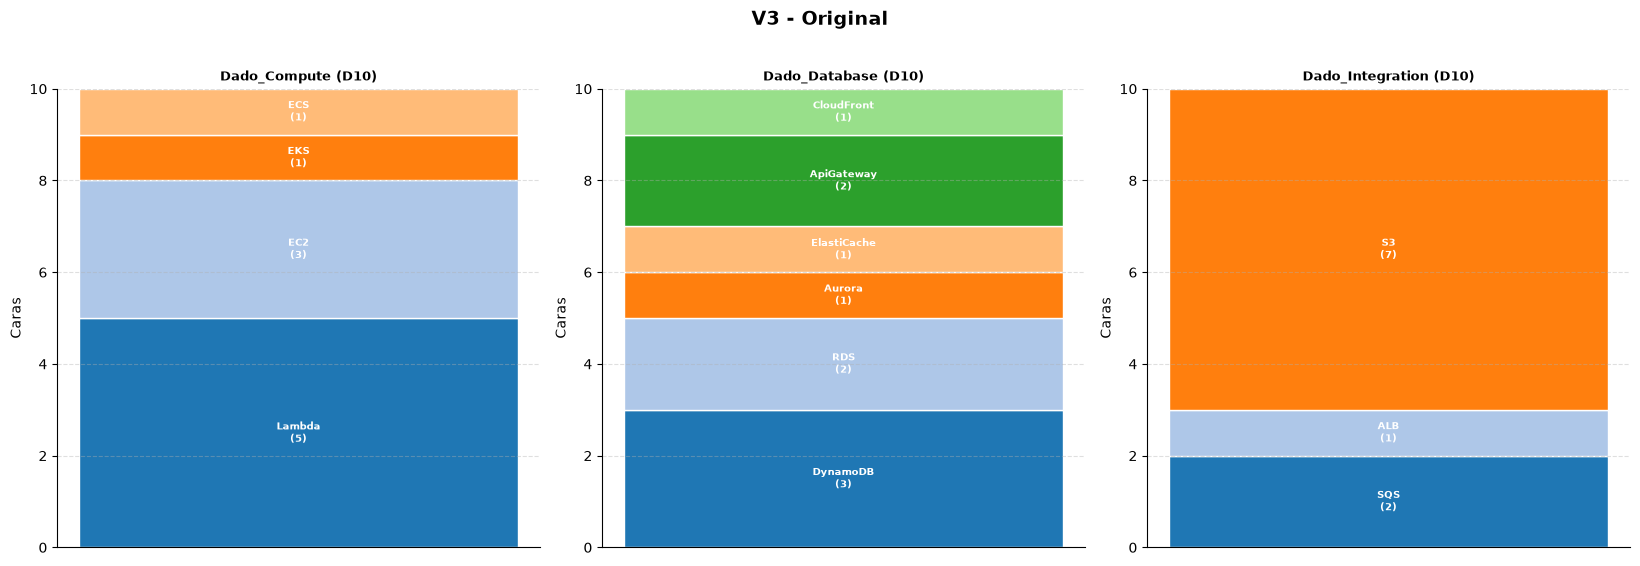

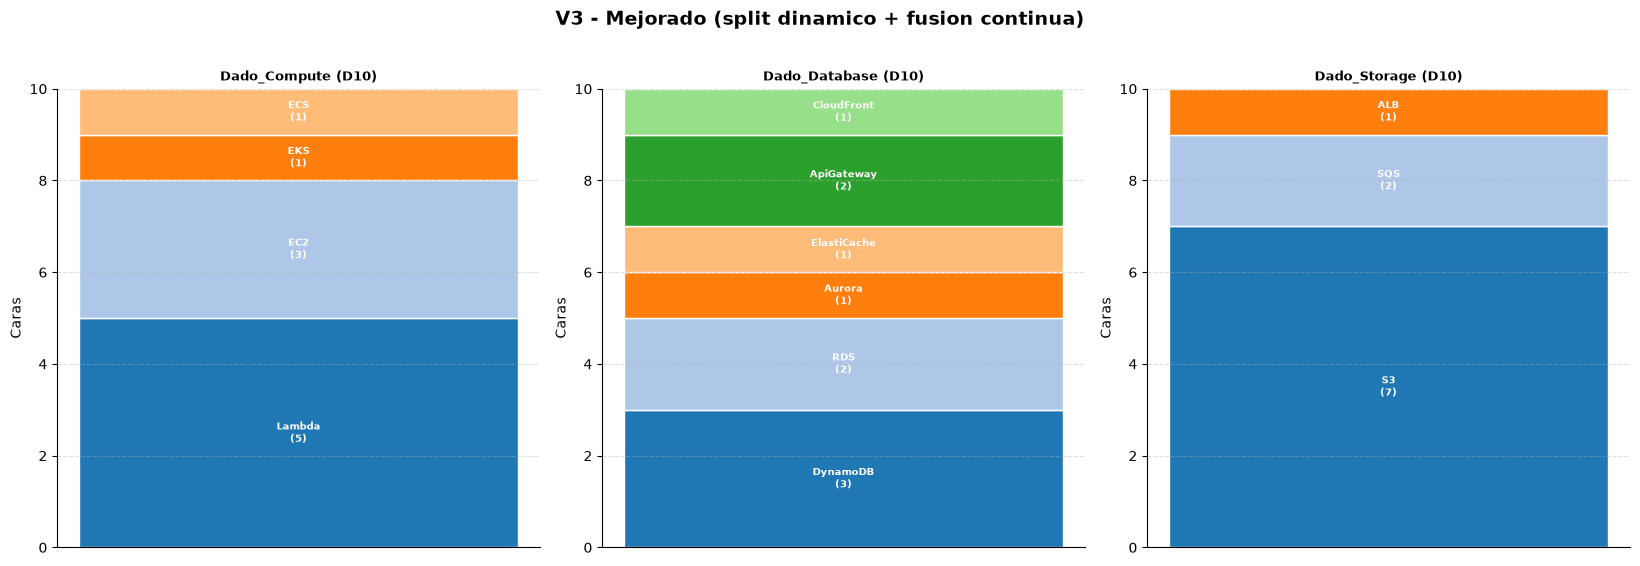

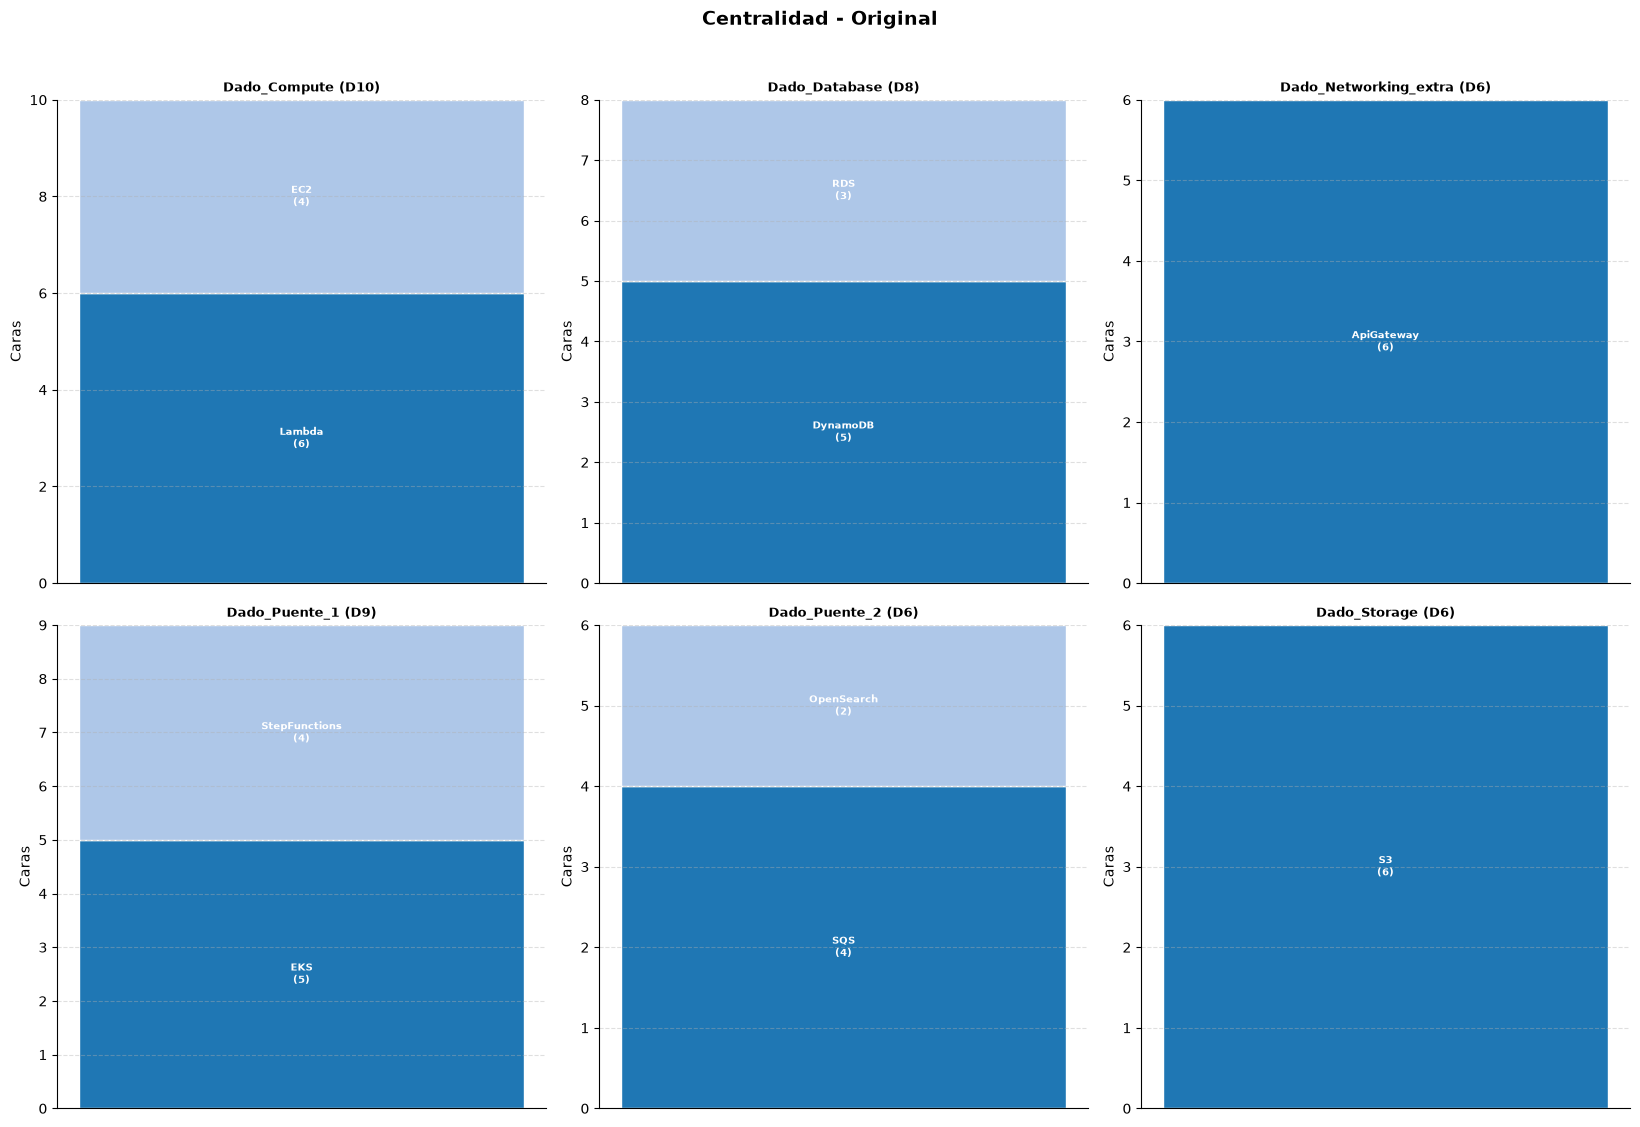

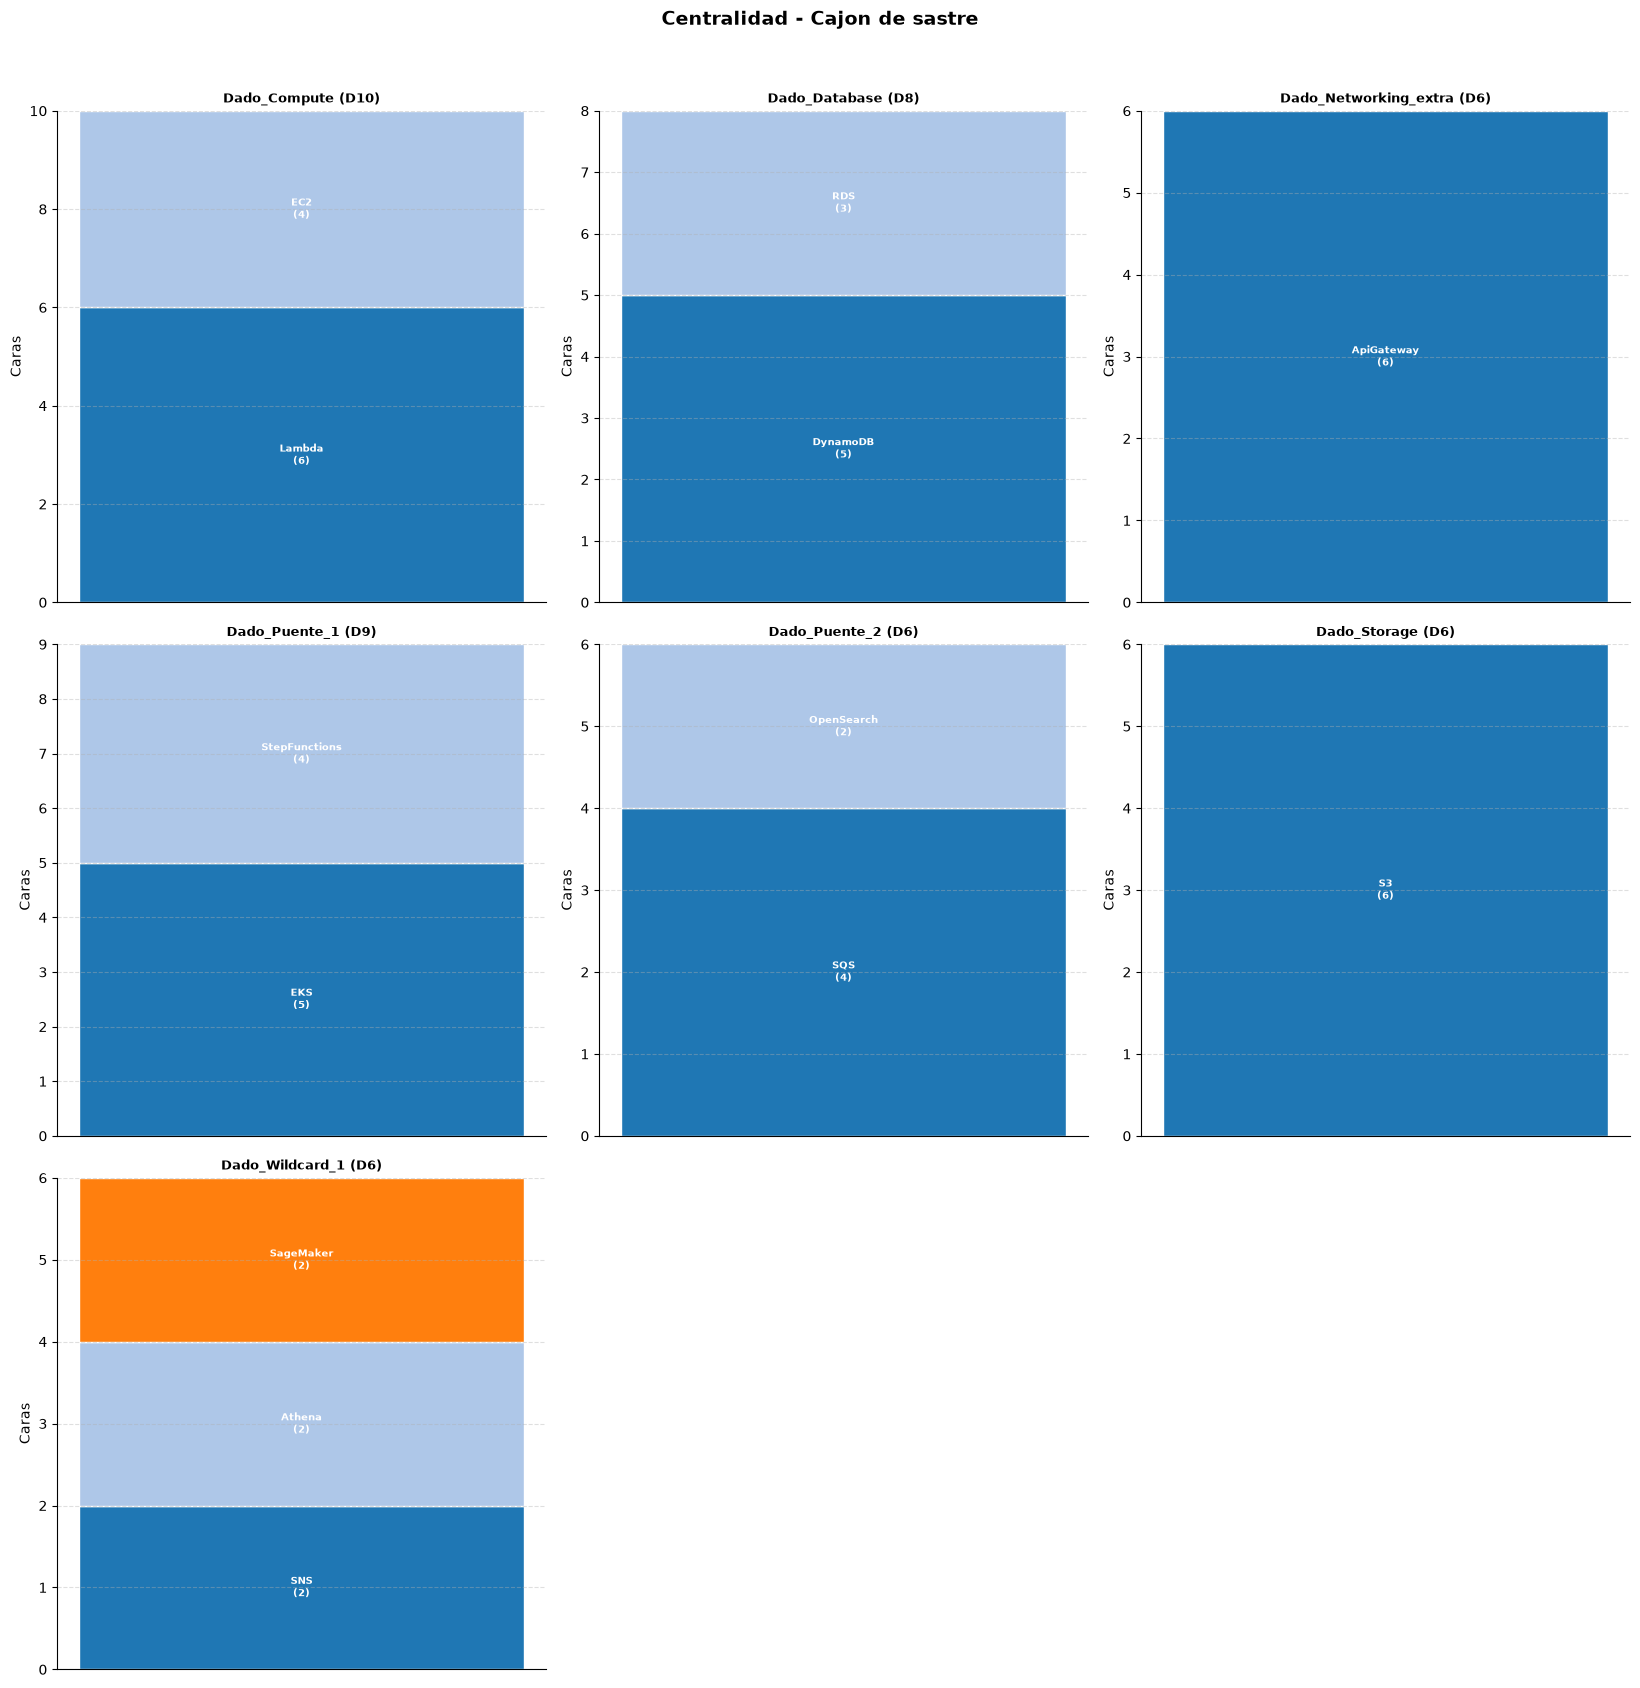

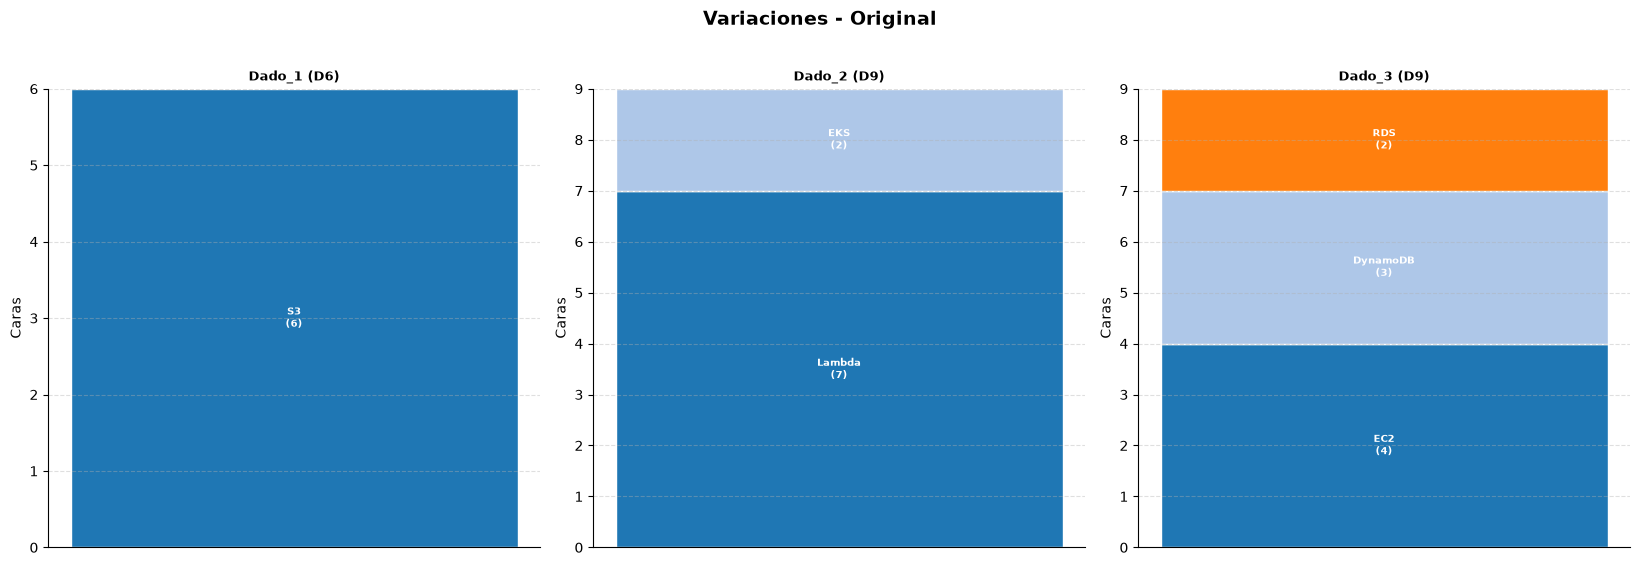

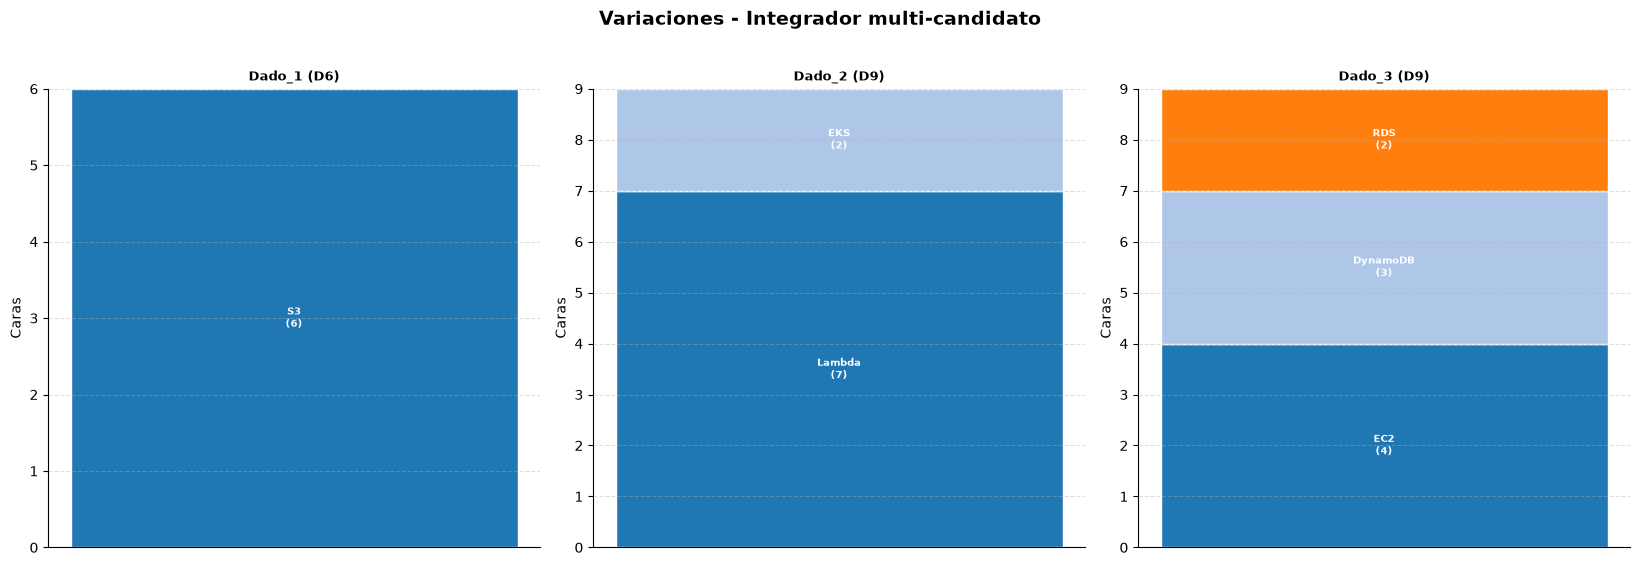

In [23]:
def graficar_set_de_dados(df_opt: pl.DataFrame, titulo: str):
    resumen = df_opt.select(['dado_id', 'forma_dado']).unique().sort('dado_id')
    dado_ids = resumen['dado_id'].to_list()
    formas = resumen['forma_dado'].to_list()

    n_dados = len(dado_ids)
    n_cols = min(3, n_dados) if n_dados > 0 else 1
    n_rows = int(np.ceil(n_dados / n_cols)) if n_dados > 0 else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5.5 * n_rows), squeeze=False)
    axes = axes.reshape(-1)
    cmap = plt.get_cmap('tab20')

    for i, (dado_id, forma) in enumerate(zip(dado_ids, formas)):
        ax = axes[i]
        df_dado = df_opt.filter(pl.col('dado_id') == dado_id)
        n_total = int(forma.replace('d', ''))
        servicios = df_dado['service'].to_list()
        caras = df_dado['num_caras'].to_list()

        bottom = 0
        for j, (serv, val) in enumerate(zip(servicios, caras)):
            ax.bar(0, val, bottom=bottom, color=cmap(j % 20), edgecolor='white', width=0.5)
            ax.text(0, bottom + val / 2, f"{serv}\n({val})", ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
            bottom += val

        ax.set_ylim(0, n_total)
        ax.set_title(f"{dado_id} ({forma.upper()})", fontweight='bold', fontsize=9)
        ax.set_xticks([])
        ax.set_ylabel('Caras')

    for k in range(n_dados, len(axes)):
        axes[k].axis('off')

    plt.suptitle(titulo, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


for nombre, df_opt in tablas_caras.items():
    graficar_set_de_dados(df_opt, nombre)

## 10. Simulacion de Tiradas

In [24]:
def simular_lanzamiento(df_opt: pl.DataFrame) -> list:
    seleccionados = []
    for dado_id, df_dado in df_opt.group_by('dado_id'):
        forma = df_dado['forma_dado'].first()
        n_total = int(forma.replace('d', ''))
        servicios = df_dado['service'].to_list()
        caras = df_dado['num_caras'].to_list()
        prob = np.array(caras) / n_total
        seleccionados.append(np.random.choice(servicios, p=prob))
    return seleccionados


def simular_variante(df_opt: pl.DataFrame, G: nx.Graph = None, n_tiradas: int = 1000) -> dict:
    if G is None:
        G = G_cooc_master
    tiradas = []
    repetidos_totales = 0
    incoherencias_totales = 0

    for _ in range(n_tiradas):
        tirada = simular_lanzamiento(df_opt)
        if len(tirada) != len(set(tirada)):
            repetidos_totales += 1
        if any(son_incompatibles(s1, s2, G) for s1, s2 in combinations(tirada, 2)):
            incoherencias_totales += 1
        tiradas.append(" | ".join(sorted(tirada)))

    df_resultados = pl.DataFrame({'arquitectura': tiradas})
    df_resumen = (
        df_resultados.group_by('arquitectura').len(name='frecuencia')
        .with_columns((pl.col('frecuencia') / n_tiradas * 100).round(2).alias('porcentaje_%'))
        .sort('frecuencia', descending=True)
    )

    return {
        'df_resumen': df_resumen,
        'repetidos': repetidos_totales,
        'incoherencias': incoherencias_totales,
        'arquitecturas_unicas': df_resumen.height,
        'n_tiradas': n_tiradas,
    }


resultados_simulacion = {}
for nombre, df_opt in tablas_caras.items():
    resultados_simulacion[nombre] = simular_variante(df_opt, G_cooc_master, n_tiradas=1000)
    print(f"{nombre}: {resultados_simulacion[nombre]['arquitecturas_unicas']} arquitecturas")

V3 - Original: 69 arquitecturas
V3 - Mejorado (split dinamico + fusion continua): 67 arquitecturas
Centralidad - Original: 16 arquitecturas
Centralidad - Cajon de sastre: 48 arquitecturas
Variaciones - Original: 6 arquitecturas
Variaciones - Integrador multi-candidato: 6 arquitecturas


## 11. Informe de Combinaciones

In [25]:
TOP_N = 10

for nombre, res in resultados_simulacion.items():
    print("=" * 70)
    print(nombre)
    print("=" * 70)
    print(f"Repetidos: {res['repetidos']} ({res['repetidos'] / res['n_tiradas'] * 100:.1f}%)")
    print(f"Incompatibles: {res['incoherencias']} ({res['incoherencias'] / res['n_tiradas'] * 100:.1f}%)")
    print(f"Unicas: {res['arquitecturas_unicas']} de {res['n_tiradas']}")

    print(f"Top {TOP_N} mas comunes:")
    with pl.Config(tbl_rows=TOP_N, fmt_str_lengths=100):
        print(res['df_resumen'].head(TOP_N))

    print(f"Top {TOP_N} menos comunes:")
    with pl.Config(tbl_rows=TOP_N, fmt_str_lengths=100):
        print(res['df_resumen'].tail(TOP_N))
    print()

V3 - Original
Repetidos: 0 (0.0%)
Incompatibles: 0 (0.0%)
Unicas: 69 de 1000
Top 10 mas comunes:
shape: (10, 3)
┌───────────────────────────┬────────────┬──────────────┐
│ arquitectura              ┆ frecuencia ┆ porcentaje_% │
│ ---                       ┆ ---        ┆ ---          │
│ str                       ┆ u32        ┆ f64          │
╞═══════════════════════════╪════════════╪══════════════╡
│ DynamoDB | Lambda | S3    ┆ 108        ┆ 10.8         │
│ ApiGateway | Lambda | S3  ┆ 67         ┆ 6.7          │
│ Lambda | RDS | S3         ┆ 66         ┆ 6.6          │
│ EC2 | RDS | S3            ┆ 58         ┆ 5.8          │
│ DynamoDB | EC2 | S3       ┆ 55         ┆ 5.5          │
│ ElastiCache | Lambda | S3 ┆ 44         ┆ 4.4          │
│ ApiGateway | EC2 | S3     ┆ 44         ┆ 4.4          │
│ Aurora | Lambda | S3      ┆ 37         ┆ 3.7          │
│ CloudFront | Lambda | S3  ┆ 32         ┆ 3.2          │
│ DynamoDB | EKS | S3       ┆ 30         ┆ 3.0          │
└─────────────────

In [26]:
filas_resumen = []
for nombre, dados in VARIANTES.items():
    res = resultados_simulacion[nombre]
    servicios_cubiertos = len(set(s for m in dados.values() for s in m))
    top = res['df_resumen'].row(0, named=True)
    bottom = res['df_resumen'].row(-1, named=True)
    filas_resumen.append({
        'variante': nombre,
        'n_dados': len(dados),
        'servicios_cubiertos': servicios_cubiertos,
        'arquitecturas_unicas_1000': res['arquitecturas_unicas'],
        'combo_mas_comun': top['arquitectura'],
        'pct_mas_comun': top['porcentaje_%'],
        'combo_menos_comun': bottom['arquitectura'],
        'pct_menos_comun': bottom['porcentaje_%'],
        'tiradas_con_repetidos': res['repetidos'],
        'tiradas_incompatibles': res['incoherencias'],
    })

df_informe_final = pl.DataFrame(filas_resumen)
print(df_informe_final)

OUTPUT_DIR = Path("output_analytics")
OUTPUT_DIR.mkdir(exist_ok=True)
df_informe_final.write_csv(OUTPUT_DIR / "informe_comparativo_variantes.csv")
print(f"Exportado: {OUTPUT_DIR / 'informe_comparativo_variantes.csv'}")

shape: (6, 10)
┌────────────┬─────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ variante   ┆ n_dados ┆ servicios ┆ arquitect ┆ … ┆ combo_men ┆ pct_menos ┆ tiradas_c ┆ tiradas_i │
│ ---        ┆ ---     ┆ _cubierto ┆ uras_unic ┆   ┆ os_comun  ┆ _comun    ┆ on_repeti ┆ ncompatib │
│ str        ┆ i64     ┆ s         ┆ as_1000   ┆   ┆ ---       ┆ ---       ┆ dos       ┆ les       │
│            ┆         ┆ ---       ┆ ---       ┆   ┆ str       ┆ f64       ┆ ---       ┆ ---       │
│            ┆         ┆ i64       ┆ i64       ┆   ┆           ┆           ┆ i64       ┆ i64       │
╞════════════╪═════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ V3 -       ┆ 3       ┆ 13        ┆ 69        ┆ … ┆ Aurora |  ┆ 0.1       ┆ 0         ┆ 0         │
│ Original   ┆         ┆           ┆           ┆   ┆ ECS | SQS ┆           ┆           ┆           │
│ V3 -       ┆ 3       ┆ 13        ┆ 67        ┆ … ┆ ALB | Api ┆ 0.1       ┆